In [1]:
import sys
!{sys.executable} -m pip install torchsummary


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchsummary import summary
import matplotlib.pyplot as plt

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
train_dataset = MNIST(root='./data', train=True, transform=ToTensor(), download=True)
test_dataset = MNIST(root='./data', train=False, transform=ToTensor())

In [5]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

In [6]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

In [7]:
model = ANN().to(device)

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
train_loss_history = []
train_acc_history = []

num_epochs = 10
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], Loss: {loss.item():.4f}')

    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = correct / total
        train_loss_history.append(loss.item())
        train_acc_history.append(train_accuracy)
        print(f'Train Accuracy: {100*train_accuracy:.2f}%')

    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = correct / total
        print(f'Test Accuracy: {100*test_accuracy:.2f}%')

Epoch [1/10], Step [100/938], Loss: 1.5951
Epoch [1/10], Step [200/938], Loss: 1.5895
Epoch [1/10], Step [300/938], Loss: 1.6428
Epoch [1/10], Step [400/938], Loss: 1.6106
Epoch [1/10], Step [500/938], Loss: 1.5225
Epoch [1/10], Step [600/938], Loss: 1.5803
Epoch [1/10], Step [700/938], Loss: 1.5666
Epoch [1/10], Step [800/938], Loss: 1.5099
Epoch [1/10], Step [900/938], Loss: 1.5691
Train Accuracy: 92.89%
Test Accuracy: 92.95%
Epoch [2/10], Step [100/938], Loss: 1.5375
Epoch [2/10], Step [200/938], Loss: 1.5527
Epoch [2/10], Step [300/938], Loss: 1.5492
Epoch [2/10], Step [400/938], Loss: 1.5232
Epoch [2/10], Step [500/938], Loss: 1.5990
Epoch [2/10], Step [600/938], Loss: 1.5142
Epoch [2/10], Step [700/938], Loss: 1.5062
Epoch [2/10], Step [800/938], Loss: 1.5829
Epoch [2/10], Step [900/938], Loss: 1.5072
Train Accuracy: 94.88%
Test Accuracy: 94.41%
Epoch [3/10], Step [100/938], Loss: 1.5023
Epoch [3/10], Step [200/938], Loss: 1.5122
Epoch [3/10], Step [300/938], Loss: 1.5002
Epoch [

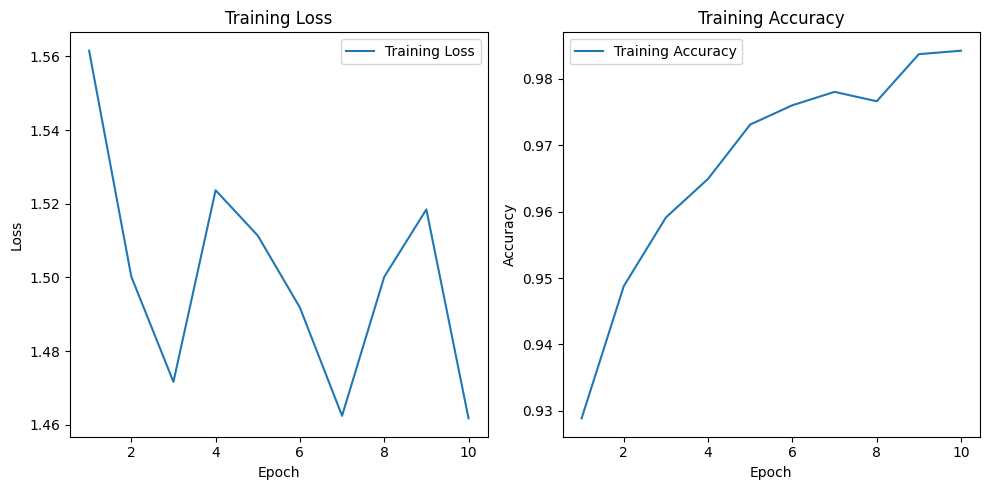

In [10]:
epochs = range(1, num_epochs+1)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_history, label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.tight_layout()
plt.show()